Проект для попытки реализовать расчёт метрик

На своих данных (двумерных для простоты)

В этом проекте, основанного на MetricsKANTest, должно быть реаплизовано автоматическое обучение сети ( 50 раз) с сохранением получившихся метрик в файл csv 

Метрики должны быть расчитаны на основе 10% данных которые никак не участвовали в обучении 

In [1]:
import numpy as np
import torch
from sklearn.model_selection import train_test_split

In [2]:
input_path='file_for_input/all_hour/SBER_tradestats_test_hour.csv'
save_metrics_path = 'file_for_output/hour_metrics/KAN/TASB_metrics.csv'

In [3]:
# Функция для вычисления метрик
def calculate_metrics(Y10, kan_predictions,name):
    
    rmse_kan = root_mean_squared_error(Y10, kan_predictions)
    mae_kan = mean_absolute_error(Y10, kan_predictions)
    mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
    r2_kan = r2_score(Y10, kan_predictions)
    msle_kan = mean_squared_log_error(Y10, kan_predictions)
    
    return rmse_kan, mae_kan, mape_kan, r2_kan, msle_kan, name

# Функция для сохранения метрик в CSV файл
def save_metrics_to_csv(metrics, filename=save_metrics_path):
    # Проверяем, существует ли файл
    try:
        df = pd.read_csv(filename)
    except FileNotFoundError:
        df = pd.DataFrame(columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])

    # Добавляем новые метрики в DataFrame
    new_row = pd.DataFrame([metrics], columns=['RMSE', 'MAE', 'MAPE', 'R2', 'MSLE', 'Name'])
    df = pd.concat([df, new_row], ignore_index=True)

    # Сохраняем DataFrame в CSV файл
    df.to_csv(filename, index=False)


In [4]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cpu


In [5]:

data = pd.read_csv(input_path)

# ['vol','val','trades','trades_b','trades_s', 'val_b','val_s','vol_b','vol_s','pr_open_hour','pr_high_hour','pr_low_hour','pr_close_hour'] <- полный список параметров



# # Создаём новую колонку, где целевая переменная смещена на -1 шаг
# data['next_pr_close_hour'] = data['pr_close_hour'].shift(-1)
# 
# # Удаляем последние строки, где нет следующего значения
# data = data.dropna()
# 
# # Формируем входные данные X и целевые метки Y
# X = data[['pr_close_hour']]  # Цена закрытия текущего часа
# Y = data['next_pr_close_hour']  # Цена закрытия следующего часа








date_df= data['tradedate'] + '-' + data['tradetime_hour'].astype(str)
X = data[['pr_open_hour']] # Не добавлются сюда другие лейблы
Y= data ['pr_close_hour']
# Разделение данных на обучающую и тестовую выборки те самые 10%
X, X10, Y, Y10 = train_test_split(X, Y, test_size=0.1, shuffle=False)
# X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [6]:
import time
# neurons_number = [1,5,10,15,20,30,50,100] - 75,40,150,200 , 2,3,4,5
# grid = [3, 6,10,20,] - 100,50,30,
# steps [20, 30, 50] - 100

#Остановились на переборе нейронов для сетки 10

# Параметры сети
secid = '123SBER'
neurons_number = 1
grid = 3
num_param= len(X.columns)
steps = 50
name = secid+ '_kan_' + 'n'+str(neurons_number) + 'g'+str(grid)+'s'+ str(steps) +'np' + str(num_param) 

rand_seed= int ( time.time() )
print ( 'rand_seed = ',rand_seed)
num_rep = 10
name

rand_seed =  1734299824


'123SBER_kan_n1g3s50np1'

In [7]:
fitdate= date_df[:len(Y)] # Даты для 90% основных данных, которые пойдут на обучение
date10 = date_df[len(Y):] # Даты для выделенных 10% данных

In [8]:
# Убедитесь, что device определен (проверить код в этой ячейке)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42, shuffle=False)
train_date= fitdate[:len(y_train)] # Даты соответствующие тренировочной выборке
test_date= fitdate[len(y_train):] # Даты соответствующие тестовой выборке ( 40% данных отправленных на обучение)


# Преобразование в тензоры PyTorch
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

# Создание правильного датасета для KAN
dataset = {
    'train_input': X_train_tensor,
    'train_label': y_train_tensor,
    'test_input': X_test_tensor,
    'test_label': y_test_tensor
}

In [9]:
print("Размер обучающей выборки (X_train):", X_train.shape)
print("Размер тестовой выборки (X_test):", X_test.shape)
print("Размер меток обучающей выборки (y_train):", y_train.shape)
print("Размер меток тестовой выборки (y_test):", y_test.shape)

Размер обучающей выборки (X_train): (6521, 1)
Размер тестовой выборки (X_test): (1151, 1)
Размер меток обучающей выборки (y_train): (6521,)
Размер меток тестовой выборки (y_test): (1151,)


In [10]:
dataset['train_input'].shape, dataset['train_label'].shape 

(torch.Size([6521, 1]), torch.Size([6521, 1]))

In [11]:
# Создание модели KAN с измененными параметрами
model = KAN(width=[1, neurons_number, 1], grid=grid, k=3, seed = rand_seed)# убрал seed=0

# Обучение модели
#results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
results = model.fit(dataset, opt="LBFGS", steps=steps)
# Вывод результатов  
train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
print(f'Train loss: {train_loss}, Test loss: {test_loss}')


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.56e-01 | reg: 6.11e+00 | : 100%|█| 50/50 [00:09<00:00,  5.12it

saving model version 0.1
Train loss: 1.7850360870361328, Test loss: 0.8562696576118469


10 % Были выделены И ИСПОЛЬЗОВАНЫ  

In [12]:

# Для KAN
X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив

In [13]:
from sklearn.metrics import *



# Оценка для KAN
rmse_kan = root_mean_squared_error(Y10, kan_predictions)
mae_kan = mean_absolute_error(Y10, kan_predictions)
mape_kan = mean_absolute_percentage_error(Y10, kan_predictions)
r2_kan = r2_score(Y10, kan_predictions)
msle_kan = mean_squared_log_error(Y10, kan_predictions)


# mse_kan = mean_squared_error(y_test, kan_predictions)
# mae_kan = mean_absolute_error(y_test, kan_predictions)
# r2_kan = r2_score(y_test, kan_predictions)


print("KAN - RMSE:", rmse_kan, "MAE:", mae_kan,"MAPE:", mape_kan, "R^2:", r2_kan,"MSLE:", msle_kan)


KAN - RMSE: 0.8566218656514607 MAE: 0.5951268336306142 MAPE: 0.0023039146346096064 R^2: 0.9924958228240325 MSLE: 1.0800961927187655e-05


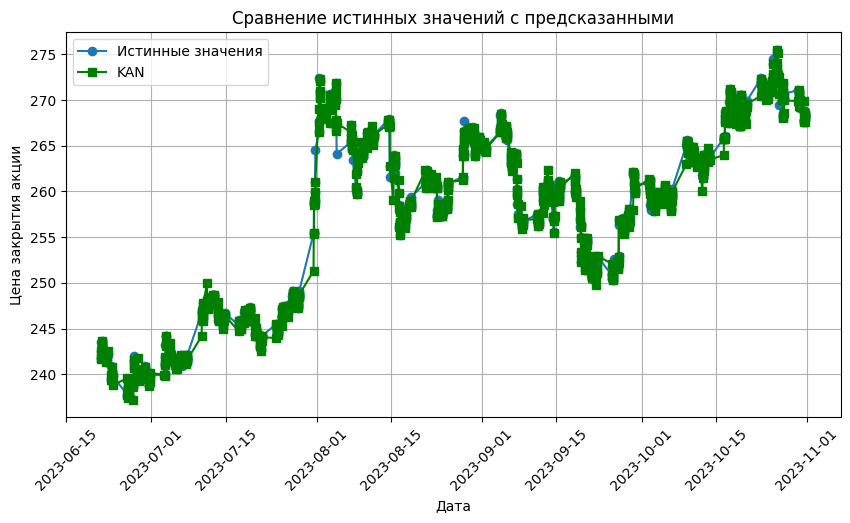

In [14]:
import matplotlib.pyplot as plt

date10 = pd.to_datetime(date10)
# Создание графика
plt.figure(figsize=(10, 5))
plt.plot(date10, Y10.reset_index(drop=True), label='Истинные значения', marker='o')
plt.plot(date10, kan_predictions, 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия акции')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемости



# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/graphics/'+name+'graph_full.png', bbox_inches='tight')
plt.show()



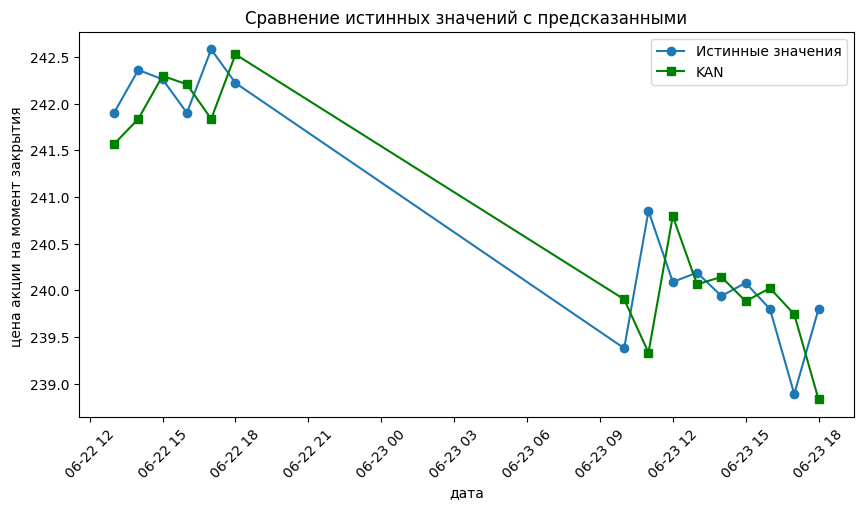

In [15]:
import matplotlib.pyplot as plt
n = 25 # До кого значения рассматривать график
k = 10 #От какого значения рассматривать график
plt.figure(figsize=(10, 5))
plt.plot(date10[k:n],Y10.reset_index(drop=True)[k:n], label='Истинные значения', marker='o')
plt.plot(date10[k:n],kan_predictions[k:n], 'g', label='KAN', marker='s')
plt.title('Сравнение истинных значений с предсказанными')
plt.xlabel('дата')
plt.ylabel('цена акции на момент закрытия ')
plt.xticks(rotation=45)  # Поворот меток дат для лучшей читаемост
plt.legend()

name = '1' + name 
# Сохранение графика в нужную директорию
plt.savefig('file_for_output/hour_metrics/KAN/graphics/'+name+'graph_part.png', bbox_inches='tight')

plt.show()


In [16]:
import random
for i in range(num_rep):  # Пример цикла
    rand_seed= random.randint(0,100000000)
    print ( 'rand_seed = ', rand_seed)
    # Создание модели KAN с измененными параметрами
    model = KAN(width=[1, neurons_number, 1], grid=grid, k=3, seed = rand_seed ) # убрал seed=0

    # Обучение модели
    #results = model2.train(dataset, opt="LBFGS", steps=20, lamb=0.01, lamb_entropy=10)
    results = model.fit(dataset, opt="LBFGS", steps=steps)
    # Вывод результатов
    train_loss = results['train_loss'][-1]  # последнее значение обучающей ошибки
    test_loss = results['test_loss'][-1]  # последнее значение ошибки на тесте
    print(f'Train loss: {train_loss}, Test loss: {test_loss}')
    
    # Для KAN
    X_test_tensor = torch.tensor(X10.values, dtype=torch.float32)  # Преобразование в тензор, если еще не сделано
    kan_predictions = model(X_test_tensor).detach().numpy()  # Получение предсказаний и преобразование их в NumPy массив
    
    
    metrics = calculate_metrics(Y10, kan_predictions, name)
    save_metrics_to_csv(metrics)

rand_seed =  86485363
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.80e+00 | test_loss: 9.98e-01 | reg: 6.80e+00 | : 100%|█| 50/50 [00:07<00:00,  6.96it


saving model version 0.1
Train loss: 1.7980490922927856, Test loss: 0.9979512095451355
rand_seed =  6989215
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.43e+02 | test_loss: 1.97e+02 | reg: 1.51e+03 | : 100%|█| 50/50 [00:06<00:00,  7.53it


saving model version 0.1
Train loss: 242.7590789794922, Test loss: 197.04933166503906
rand_seed =  36846732
checkpoint directory created: ./model
saving model version 0.0


...

saving model version 0.1
Train loss: 1.792033314704895, Test loss: 0.9871487617492676
rand_seed =  88991519
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.78e+00 | test_loss: 8.73e-01 | reg: 8.69e+00 | : 100%|█| 50/50 [00:08<00:00,  5.65it


saving model version 0.1
Train loss: 1.7821569442749023, Test loss: 0.8725706934928894
rand_seed =  49785729
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.79e+00 | test_loss: 8.54e-01 | reg: 6.00e+00 | : 100%|█| 50/50 [00:03<00:00, 12.85it

saving model version 0.1
Train loss: 1.7853808403015137, Test loss: 0.854121744632721
